# World Cup 2026 — Predictive Modeling Pipeline

A hybrid **Machine Learning + Monte Carlo** engine that simulates the entire 48-team, 104-match tournament using 49,000+ historical international matches (1872–2026).

**Phases:**
1. Environment Setup & Data Ingestion
2. Data Cleaning & Normalization
3. Custom K-Factor Elo Rating Engine
4. ML Feature Engineering
5. Model Development & Evaluation (LR / RF / XGBoost)
6. Poisson Goal Probability Layer
7. Monte Carlo Tournament Simulation (10,000 iterations)


### Libraries & Data Loading


In [1]:
# Core
import pandas as pd
import numpy as np

# ── Reproducibility ──────────────────────────────────────
import numpy as np
SEED = 42
np.random.seed(SEED)
# ─────────────────────────────────────────────────────────
# Visualization (later phases)
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime

In [2]:
# Load datasets
results = pd.read_csv("results.csv")
shootouts = pd.read_csv("shootouts.csv")
former_names = pd.read_csv("former_names.csv")

# Quick inspection
print("Results shape:", results.shape)
print("Shootouts shape:", shootouts.shape)
print("Former names shape:", former_names.shape)

results.head()

Results shape: (49287, 9)
Shootouts shape: (675, 5)
Former names shape: (36, 4)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
# Check columns
print("Results columns:", results.columns.tolist())

# Check missing values
print(results.isnull().sum())

# Check date format
results["date"] = pd.to_datetime(results["date"])

# Confirm conversion
print(results["date"].dtype)

results.duplicated().sum()
teams = set(results["home_team"]).union(set(results["away_team"]))
print("Total teams:", len(teams))
print(results["date"].min(), results["date"].max())

Results columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64
datetime64[ns]
Total teams: 333
1872-11-30 00:00:00 2026-06-27 00:00:00


## Phase 2: Advanced Data Pipeline & Cleaning
This section handles name normalization (using `former_names.csv`), tournament categorization, and win/loss/draw classification.

### Data Cleaning & Standardization


In [4]:
df = results.copy()
# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# Ensure scores are numeric
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")



### Handling Missing Values & Duplicates


In [5]:
# Check missing
print(df.isnull().sum())

# Drop rows with missing scores/Duplicates (cannot use them)
df = df.dropna(subset=["home_score", "away_score"])
df = df.drop_duplicates()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


### Filtering Date Scope & Standardizing Team Names


In [6]:
# Keep modern football (last 15–20 years)
df = df[df["date"] >= "2005-01-01"]
name_map = dict(zip(former_names["former"], former_names["current"]))


In [7]:
# Apply name normalization mapping
df["home_team"] = df["home_team"].replace(name_map)
df["away_team"] = df["away_team"].replace(name_map)

#Verify the output is as desiered
teams = set(df["home_team"]).union(set(df["away_team"]))
print("Unique teams:", len(teams))

Unique teams: 316


### Standardizing Tournament Names


In [8]:
def simplify_tournament(t):
    if "World Cup" in t:
        return "World Cup"
    elif "Qualifier" in t:
        return "Qualifier"
    elif "Friendly" in t:
        return "Friendly"
    elif "Euro" in t or "Copa" in t or "Cup" in t:
        return "Regional"
    else:
        return "Other"

df["tournament_type"] = df["tournament"].apply(simplify_tournament)

### Computing Match Results & Sorting


In [9]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "H"
    elif row["home_score"] < row["away_score"]:
        return "A"
    else:
        return "D"

df["result"] = df.apply(get_result, axis=1)

df = df.sort_values("date").reset_index(drop=True)

In [10]:
print(df.head())
print(df.tail())
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Total matches:", len(df))

        date  home_team      away_team  home_score  away_score  \
0 2005-01-02  Singapore        Myanmar         4.0         2.0   
1 2005-01-03   Malaysia      Indonesia         1.0         4.0   
2 2005-01-08      Egypt         Uganda         3.0         0.0   
3 2005-01-08  Indonesia      Singapore         1.0         3.0   
4 2005-01-08    Jamaica  French Guiana         5.0         0.0   

                        tournament          city    country  neutral  \
0                 AFF Championship     Singapore  Singapore    False   
1                 AFF Championship  Kuala Lumpur   Malaysia    False   
2                         Friendly         Cairo      Egypt    False   
3                 AFF Championship       Jakarta  Indonesia    False   
4  CFU Caribbean Cup qualification      Kingston    Jamaica    False   

  tournament_type result  
0           Other      H  
1           Other      A  
2        Friendly      H  
3           Other      A  
4        Regional      H  
        

## Phase 3: ELO Rating System Implementation
The Elo engine calculates rolling team strengths using tournament-weighted K-factors and home advantage adjustments.

### Building the Elo Rating System


In [11]:
from collections import defaultdict

# Initialize Elo ratings
elo = defaultdict(lambda: 1500)

# Storage columns
df["elo_home_pre"] = 0.0
df["elo_away_pre"] = 0.0

In [12]:
# Define Parameters
# Base K-factor
BASE_K = 20

# Tournament importance
K_FACTOR = {
    "World Cup": 60,
    "Qualifier": 40,
    "Regional": 30,
    "Other": 20,
    "Friendly": 10
}

# Home advantage boost (in Elo points)
HOME_ADV = 100


#Exepected score
def expected_score(rA, rB):
    return 1 / (1 + 10 ** ((rB - rA) / 400))

In [13]:
# Main Elo update loop (optimized: numpy arrays + inline goal margin)
n = len(df)
elo_home_arr = np.zeros(n)
elo_away_arr = np.zeros(n)

home_teams = df["home_team"].values
away_teams = df["away_team"].values
home_scores = df["home_score"].values
away_scores = df["away_score"].values
neutrals = df["neutral"].values
tourn_types = df["tournament_type"].values

for idx in range(n):
    home = home_teams[idx]
    away = away_teams[idx]

    R_home = elo[home]
    R_away = elo[away]

    # Store PRE-MATCH ratings (no leakage)
    elo_home_arr[idx] = R_home
    elo_away_arr[idx] = R_away

    # Home advantage
    R_home_adj = R_home + HOME_ADV if not neutrals[idx] else R_home

    # Expected scores
    E_home = expected_score(R_home_adj, R_away)

    # Actual result
    hs, as_ = home_scores[idx], away_scores[idx]
    S_home = 1.0 if hs > as_ else (0.5 if hs == as_ else 0.0)

    # K-factor + goal margin multiplier
    K = K_FACTOR.get(tourn_types[idx], BASE_K)
    goal_diff = abs(hs - as_)
    denom = (R_home - R_away) * 0.001 + 2.2
    multiplier = np.log(goal_diff + 1) * 2.2 / denom

    # Update Elo ratings
    elo[home] = R_home + K * multiplier * (S_home - E_home)
    elo[away] = R_away + K * multiplier * ((1 - S_home) - (1 - E_home))

# Bulk write back to DataFrame
df["elo_home_pre"] = elo_home_arr
df["elo_away_pre"] = elo_away_arr

print(df[["home_team", "away_team", "elo_home_pre", "elo_away_pre"]].head())
print(f"\nElo update complete: {n} matches processed")


   home_team      away_team  elo_home_pre  elo_away_pre
0  Singapore        Myanmar    1500.00000    1500.00000
1   Malaysia      Indonesia    1500.00000    1500.00000
2      Egypt         Uganda    1500.00000    1500.00000
3  Indonesia      Singapore    1517.74637    1507.90858
4    Jamaica  French Guiana    1500.00000    1500.00000

Elo update complete: 20292 matches processed


## Phase 4: ML Feature Engineering
Calculating recency form, goal strength indices, and preparing the final feature matrix for model training.

### Feature Engineering


In [14]:
# Core Elo differential features
df["elo_diff"] = df["elo_home_pre"] - df["elo_away_pre"]

#Home Adv
df["home_advantage"] = df["neutral"].apply(lambda x: 0 if x else 1)

#Tourment Importance
weights = {
    "World Cup": 5,
    "Qualifier": 4,
    "Regional": 3,
    "Other": 2,
    "Friendly": 1
}

df["tournament_weight"] = df["tournament_type"].map(weights)


In [15]:
# Recent form features (optimized: numpy arrays, no df.at)
from collections import defaultdict

form_points = defaultdict(list)
home_form_arr = np.zeros(n)
away_form_arr = np.zeros(n)
results_arr = df["result"].values

for idx in range(n):
    home = home_teams[idx]
    away = away_teams[idx]

    # Calculate average points (last 5 matches)
    home_form_arr[idx] = np.mean(form_points[home][-5:]) if form_points[home] else 0
    away_form_arr[idx] = np.mean(form_points[away][-5:]) if form_points[away] else 0

    # Assign points
    r = results_arr[idx]
    if r == "H":
        form_points[home].append(3)
        form_points[away].append(0)
    elif r == "A":
        form_points[home].append(0)
        form_points[away].append(3)
    else:
        form_points[home].append(1)
        form_points[away].append(1)

df["home_form"] = home_form_arr
df["away_form"] = away_form_arr
df["form_diff"] = home_form_arr - away_form_arr


In [16]:
# Goal strength features (optimized: numpy arrays, no df.at)
goals_scored = defaultdict(list)
goals_conceded = defaultdict(list)
home_attack_arr = np.zeros(n)
away_attack_arr = np.zeros(n)

for idx in range(n):
    home = home_teams[idx]
    away = away_teams[idx]

    home_attack_arr[idx] = np.mean(goals_scored[home][-5:]) if goals_scored[home] else 0
    away_attack_arr[idx] = np.mean(goals_scored[away][-5:]) if goals_scored[away] else 0

    goals_scored[home].append(home_scores[idx])
    goals_scored[away].append(away_scores[idx])
    goals_conceded[home].append(away_scores[idx])
    goals_conceded[away].append(home_scores[idx])

df["home_attack"] = home_attack_arr
df["away_attack"] = away_attack_arr
df["attack_diff"] = home_attack_arr - away_attack_arr


In [17]:
# Assemble final feature set
features = [
    "elo_diff",
    "form_diff",
    "attack_diff",
    "home_advantage",
    "tournament_weight"
]

## Phase 5: Model Development & Evaluation
Implementing time-based splits (no random shuffling) and comparing classification performance between Logistic Regression, Random Forest, and XGBoost models.

### Train / Test Split


In [18]:
# Time-based split — NO random shuffling!
split_date = "2022-01-01"

train = df[df["date"] < split_date]
test  = df[df["date"] >= split_date]

X_train = train[features]
y_train = train["result"]

X_test = test[features]
y_test = test["result"]

print("Train size:", len(train), "| Test size:", len(test))
print("Class distribution (train):\n", y_train.value_counts(normalize=True))

Train size: 15878 | Test size: 4414
Class distribution (train):
 result
H    0.480098
A    0.286686
D    0.233216
Name: proportion, dtype: float64


### Quick Exploratory Data Analysis (EDA)


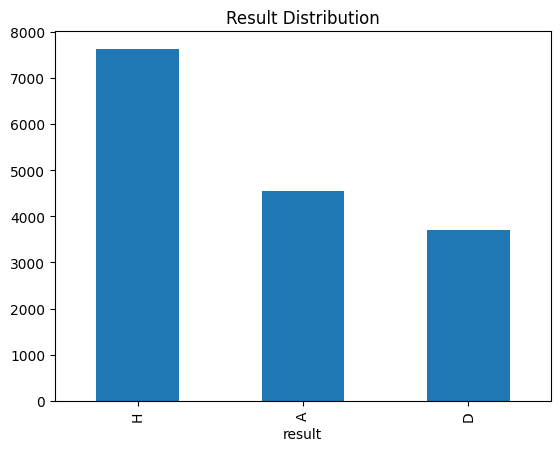

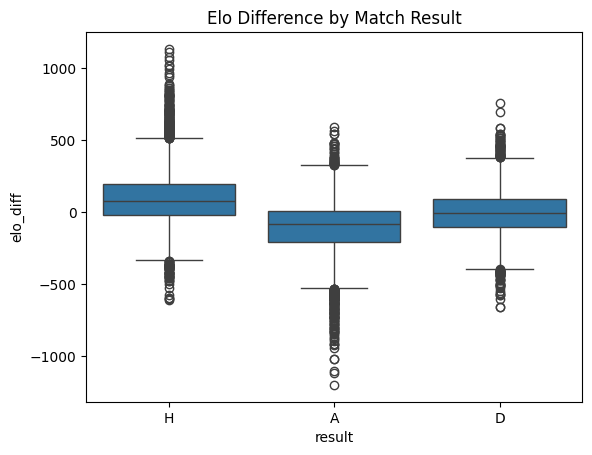

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class balance — are wins/draws/losses evenly distributed?
y_train.value_counts().plot(kind="bar", title="Result Distribution")
plt.show()

# 2. Elo diff vs result — does Elo actually separate outcomes?
sns.boxplot(x="result", y="elo_diff", data=train)
plt.title("Elo Difference by Match Result")
plt.show()

### Model Training


=== Logistic Regression ===
Accuracy: 0.561

              precision    recall  f1-score   support

           A       0.53      0.66      0.58      1303
           D       0.28      0.20      0.23      1015
           H       0.69      0.68      0.68      2096

    accuracy                           0.56      4414
   macro avg       0.50      0.51      0.50      4414
weighted avg       0.54      0.56      0.55      4414



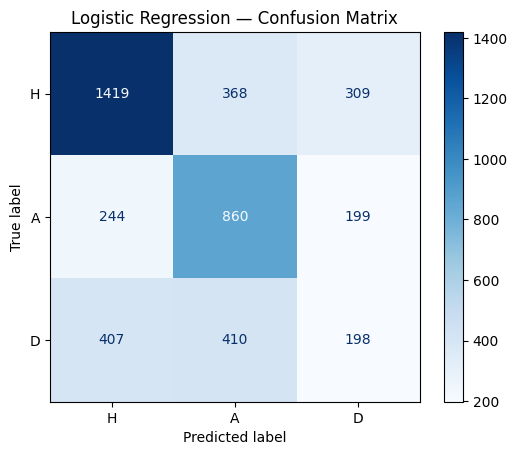

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Scale features (Logistic Regression is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit only on train — never on test!

# 2. Train
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)


# 3. Evaluate
y_pred = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy: {lr.score(X_test_scaled, y_test):.3f}\n")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["H", "A", "D"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["H", "A", "D"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

### Model Comparison


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, log_loss
from sklearn.preprocessing import LabelEncoder

# Encode labels for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Define models
models = {
    "Logistic Regression": lr,  # already trained
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, eval_metric="mlogloss", random_state=42),
    "SVM": SVC(class_weight="balanced", probability=True, random_state=42)
}

results_summary = []

for name, model in models.items():
    # Train (LR is already trained)
    if name == "XGBoost":
        model.fit(X_train_scaled, y_train_enc)
        y_pred_enc = model.predict(X_test_scaled)
        y_pred = le.inverse_transform(y_pred_enc)
        y_proba = model.predict_proba(X_test_scaled)
        ll = log_loss(y_test_enc, y_proba)
    elif name != "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)
        ll = log_loss(y_test, y_proba)
    else:
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)
        ll = log_loss(y_test, y_proba)

    acc = (y_pred == y_test.values).mean()
    f1  = f1_score(y_test, y_pred, average="weighted")

    results_summary.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Weighted F1": round(f1, 3),
        "Log Loss": round(ll, 3)
    })
    print(f"✅ {name} done")

# Print comparison table
results_df = pd.DataFrame(results_summary).sort_values("Weighted F1", ascending=False)
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

✅ Logistic Regression done
✅ Random Forest done
✅ XGBoost done
✅ SVM done

=== MODEL COMPARISON ===
              Model  Accuracy  Weighted F1  Log Loss
Logistic Regression     0.561        0.549     0.933
                SVM     0.555        0.549     0.927
      Random Forest     0.549        0.524     1.095
            XGBoost     0.570        0.524     0.977


In [22]:
# See if XGBoost is ignoring draws again
from sklearn.metrics import classification_report

# Repredict with XGBoost
y_pred_xgb = le.inverse_transform(models["XGBoost"].predict(X_test_scaled))

print("=== XGBoost Class Breakdown ===")
print(classification_report(y_test, y_pred_xgb))

print("=== Logistic Regression Class Breakdown ===")
print(classification_report(y_test, models["Logistic Regression"].predict(X_test_scaled)))

=== XGBoost Class Breakdown ===
              precision    recall  f1-score   support

           A       0.54      0.59      0.56      1303
           D       0.29      0.08      0.12      1015
           H       0.61      0.80      0.69      2096

    accuracy                           0.57      4414
   macro avg       0.48      0.49      0.46      4414
weighted avg       0.52      0.57      0.52      4414

=== Logistic Regression Class Breakdown ===
              precision    recall  f1-score   support

           A       0.53      0.66      0.58      1303
           D       0.28      0.20      0.23      1015
           H       0.69      0.68      0.68      2096

    accuracy                           0.56      4414
   macro avg       0.50      0.51      0.50      4414
weighted avg       0.54      0.56      0.55      4414



## Phase 6: Tournament Simulation Engine (Elo-Poisson)
Integrating a Poisson distribution model with a 10,000-run Monte Carlo engine to simulate the 2026 World Cup 48-team bracket.

### Poisson Goal Probability Layer


In [23]:
from scipy.stats import poisson

# Build attack/defense strength per team using recent data
recent = df[df["date"] >= "2022-01-01"].copy()

# Average goals scored/conceded per team
home_stats = recent.groupby("home_team").agg(
    home_scored=("home_score", "mean"),
    home_conceded=("away_score", "mean")
).reset_index()

away_stats = recent.groupby("away_team").agg(
    away_scored=("away_score", "mean"),
    away_conceded=("home_score", "mean")
).reset_index()

# Merge into one team stats table
team_stats = pd.merge(
    home_stats, away_stats,
    left_on="home_team", right_on="away_team",
    how="outer"
).fillna(0)

team_stats["team"] = team_stats["home_team"].fillna(team_stats["away_team"])
team_stats["attack"]  = (team_stats["home_scored"]  + team_stats["away_scored"])  / 2
team_stats["defense"] = (team_stats["home_conceded"] + team_stats["away_conceded"]) / 2

team_stats = team_stats[["team", "attack", "defense"]].set_index("team")

# Global average goals per game
avg_goals = recent["home_score"].mean()
print(f"Average goals per game: {avg_goals:.2f}")
print(f"\nSample team stats:")
print(team_stats.loc[team_stats.index.isin(["Brazil", "France", "Argentina", "England", "Morocco"])])

Average goals per game: 1.59

Sample team stats:
             attack   defense
team                         
Argentina  2.208978  0.469040
Brazil     1.937500  0.937500
England    2.009375  0.706250
France     2.124644  0.910969
Morocco    1.725490  0.705882


### Group Stage Simulation


In [24]:
from collections import defaultdict
import numpy as np

# Recency-weighted form — recent matches matter more than older ones
def get_recent_form(team, n=10):
    """
    Gets last N matches for a team and returns weighted form score.
    More recent matches are weighted higher.
    """
    team_matches = df[
        (df["home_team"] == team) | (df["away_team"] == team)
    ].sort_values("date").tail(n)

    if len(team_matches) == 0:
        return 1.0  # neutral

    scores = []
    for _, row in team_matches.iterrows():
        if row["home_team"] == team:
            if row["result"] == "H": scores.append(3)
            elif row["result"] == "D": scores.append(1)
            else: scores.append(0)
        else:
            if row["result"] == "A": scores.append(3)
            elif row["result"] == "D": scores.append(1)
            else: scores.append(0)

    # Exponential weights — most recent match has highest weight
    weights = np.exp(np.linspace(0, 1, len(scores)))
    weighted_score = np.average(scores, weights=weights)

    # Normalize to a multiplier around 1.0 (max possible = 3.0)
    return weighted_score / 1.5  # 1.0 = average form

# Test it
for team in ["Argentina", "France", "Brazil", "England", "Morocco"]:
    print(f"{team}: {get_recent_form(team):.3f}")

Argentina: 1.724
France: 1.751
Brazil: 1.113
England: 1.371
Morocco: 1.567


In [25]:
def dixon_coles_correction(home_goals, away_goals, lambda_home, lambda_away, rho=-0.13):
    """
    Dixon-Coles correction adjusts the probabilities of low-scoring matches (0-0, 1-0, 0-1, 1-1).
    Standard Poisson models under-predict draws and low-scoring matches. This reweighting
    introduces dependence between home and away goals to correct that bias.
    """
    weights = np.ones_like(home_goals, dtype=float)
    
    mask_00 = (home_goals == 0) & (away_goals == 0)
    weights[mask_00] = 1 - lambda_home * lambda_away * rho
    
    mask_01 = (home_goals == 0) & (away_goals == 1)
    weights[mask_01] = 1 + lambda_home * rho
    
    mask_10 = (home_goals == 1) & (away_goals == 0)
    weights[mask_10] = 1 + lambda_away * rho
    
    mask_11 = (home_goals == 1) & (away_goals == 1)
    weights[mask_11] = 1 - rho
    
    return np.maximum(weights, 0.0)

def simulate_match(home_team, away_team, neutral=False, n_simulations=10000, rho=-0.13):
    """
    Hybrid simulator: Elo + Poisson + recent form + attack/defense strength
    """
    # --- Elo Component ---
    elo_home = elo.get(home_team, 1500)
    elo_away = elo.get(away_team, 1500)
    elo_diff = elo_home - elo_away
    elo_scale = 1 / (1 + 10 ** (-elo_diff / 400))  # 0 to 1

    # --- Attack / Defense Component ---
    home_att = team_stats.loc[home_team, "attack"]  if home_team in team_stats.index else avg_goals
    home_def = team_stats.loc[home_team, "defense"] if home_team in team_stats.index else avg_goals
    away_att = team_stats.loc[away_team, "attack"]  if away_team in team_stats.index else avg_goals
    away_def = team_stats.loc[away_team, "defense"] if away_team in team_stats.index else avg_goals

    # --- Recent Form Component ---
    form_home = get_recent_form(home_team)
    form_away = get_recent_form(away_team)

    # --- Home Advantage ---
    home_adv = 0.15 if not neutral else 0.0

    # --- Blend everything into expected goals (lambda) ---
    # Poisson base: average of team attack vs opponent defense
    base_home = (home_att + away_def) / 2
    base_away = (away_att + home_def) / 2

    # Scale by Elo (0.7 to 1.3 range — don't let Elo dominate completely)
    elo_multiplier_home = 0.7 + (elo_scale * 0.6)
    elo_multiplier_away = 0.7 + ((1 - elo_scale) * 0.6)

    # Apply form and home advantage
    lambda_home = max(0.3, base_home * elo_multiplier_home * form_home + home_adv)
    lambda_away = max(0.3, base_away * elo_multiplier_away * form_away)

    # --- Monte Carlo Simulation ---
    home_goals_sim = np.random.poisson(lambda_home, n_simulations)
    away_goals_sim = np.random.poisson(lambda_away, n_simulations)

    # Apply Dixon-Coles correction as a reweighting step
    weights = dixon_coles_correction(home_goals_sim, away_goals_sim, lambda_home, lambda_away, rho)
    weight_sum = weights.sum()

    home_wins = (weights[home_goals_sim > away_goals_sim]).sum() / weight_sum
    draws     = (weights[home_goals_sim == away_goals_sim]).sum() / weight_sum
    away_wins = (weights[home_goals_sim < away_goals_sim]).sum() / weight_sum

    # Most likely scoreline
    home_score = int(round(lambda_home))
    away_score = int(round(lambda_away))

    return {
        "home": home_team,
        "away": away_team,
        "score": f"{home_score} - {away_score}",
        "home_goals": home_score,
        "away_goals": away_score,
        "prob_home": round(home_wins, 3),
        "prob_draw": round(draws, 3),
        "prob_away": round(away_wins, 3),
        "lambda_home": round(lambda_home, 3),
        "lambda_away": round(lambda_away, 3),
    }

# Sanity check
tests = [
    ("Argentina", "France", True),
    ("Brazil", "England", True),
    ("Morocco", "Spain", True),
    ("Egypt", "Ghana", False),
]

print("=== Upgraded Match Simulator ===\n")
for home, away, neutral in tests:
    r = simulate_match(home, away, neutral=neutral)
    print(f"{home} vs {away}")
    print(f"  Score:    {r['score']}")
    print(f"  Lambdas:  {home} {r['lambda_home']} | {away} {r['lambda_away']}")
    print(f"  Win%:     {home} {r['prob_home']:.0%} | Draw {r['prob_draw']:.0%} | {away} {r['prob_away']:.0%}\n")

=== Upgraded Match Simulator ===

Argentina vs France
  Score:    3 - 2
  Lambdas:  Argentina 2.565 | France 2.375
  Win%:     Argentina 43% | Draw 20% | France 37%

Brazil vs England
  Score:    1 - 2
  Lambdas:  Brazil 1.337 | England 2.204
  Win%:     Brazil 21% | Draw 23% | England 56%

Morocco vs Spain
  Score:    2 - 3
  Lambdas:  Morocco 1.732 | Spain 2.737
  Win%:     Morocco 23% | Draw 18% | Spain 58%

Egypt vs Ghana
  Score:    2 - 1
  Lambdas:  Egypt 1.868 | Ghana 0.66
  Win%:     Egypt 65% | Draw 24% | Ghana 11%



In [26]:
from itertools import combinations

# Compute group standings
wc_groups = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Saudi Arabia", "Uruguay", "Cape Verde"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}



def simulate_group(group_name, teams):
    table = {team: {"P":0,"W":0,"D":0,"L":0,"GF":0,"GA":0,"GD":0,"Pts":0} for team in teams}
    match_results = []

    for home, away in combinations(teams, 2):
        result = simulate_match(home, away, neutral=True)
        hg, ag = result["home_goals"], result["away_goals"]

        for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
            table[team]["P"]  += 1
            table[team]["GF"] += gf
            table[team]["GA"] += ga
            table[team]["GD"]  = table[team]["GF"] - table[team]["GA"]

        if hg > ag:
            table[home]["W"] += 1; table[home]["Pts"] += 3; table[away]["L"] += 1
        elif hg < ag:
            table[away]["W"] += 1; table[away]["Pts"] += 3; table[home]["L"] += 1
        else:
            table[home]["D"] += 1; table[home]["Pts"] += 1
            table[away]["D"] += 1; table[away]["Pts"] += 1

        match_results.append({"Group": group_name, "Home": home, "Away": away, "Score": result["score"]})

    standings = pd.DataFrame(table).T.sort_values(["Pts","GD","GF"], ascending=False).astype(int)
    return standings, match_results


all_standings = {}
all_matches   = []
all_thirds    = []  # collect all 3rd place teams for best-8 logic

print("=" * 55)
for group_name, teams in wc_groups.items():
    standings, matches = simulate_group(group_name, teams)
    all_standings[group_name] = standings
    all_matches.extend(matches)

    # Store 3rd place team with their stats
    third_team = standings.index[2]
    third_row  = standings.iloc[2]
    all_thirds.append({
        "team":  third_team,
        "group": group_name,
        "Pts":   int(third_row["Pts"]),
        "GD":    int(third_row["GD"]),
        "GF":    int(third_row["GF"]),
    })

    print(f"\n📋 GROUP {group_name}")
    print(standings[["W","D","L","GF","GA","GD","Pts"]].to_string())
    top2 = standings.index[:2].tolist()
    print(f"  ✅ Qualify: {top2[0]} & {top2[1]}  |  👀 3rd: {third_team} ({int(third_row['Pts'])}pts)")

print("\n" + "=" * 55)


# ============================================================
# 2. BEST 8 THIRD-PLACE TEAMS
# ============================================================

thirds_df = pd.DataFrame(all_thirds).sort_values(
    ["Pts", "GD", "GF"], ascending=False
).reset_index(drop=True)

best_thirds      = thirds_df.head(8)["team"].tolist()
eliminated_early = thirds_df.tail(4)["team"].tolist()

print("\n🏅 BEST 8 THIRD-PLACE TEAMS (advance to R32):")
print(thirds_df[["team","group","Pts","GD","GF"]].to_string(index=False))
print(f"\n❌ Eliminated: {eliminated_early}")


# ============================================================
# 3. BUILD ROUND OF 32
# ============================================================

# Top 2 from each group
qualifiers = {}
for group_name, standings in all_standings.items():
    qualifiers[f"{group_name}1"] = standings.index[0]
    qualifiers[f"{group_name}2"] = standings.index[1]

# Add best 8 thirds (labelled T1-T8)
for i, team in enumerate(best_thirds, 1):
    qualifiers[f"T{i}"] = team

print("\n🏆 ROUND OF 32 QUALIFIERS:")
for slot, team in qualifiers.items():
    print(f"  {slot}: {team}")


# ============================================================
# 4. KNOCKOUT STAGE SIMULATOR
# ============================================================

def knockout_match(team1, team2):
    """Simulate a knockout match — no draws allowed, penalties if needed."""
    result = simulate_match(team1, team2, neutral=True)
    hg, ag = result["home_goals"], result["away_goals"]

    if hg > ag:
        winner, score = team1, result["score"]
    elif ag > hg:
        winner, score = team2, result["score"]
    else:
        # Penalties — use Elo to give slight edge
        elo1 = elo.get(team1, 1500)
        elo2 = elo.get(team2, 1500)
        pen_prob = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
        winner = team1 if np.random.random() < pen_prob else team2
        score  = f"{result['score']} (pens)"

    return winner, score


def simulate_knockout_round(teams, round_name):
    """Simulate a full knockout round."""
    print(f"\n{'='*55}")
    print(f"  🥊 {round_name}")
    print(f"{'='*55}")

    winners = []
    for i in range(0, len(teams), 2):
        if i + 1 >= len(teams):
            # Bye — shouldn't happen with 32 teams but just in case
            winners.append(teams[i])
            continue

        t1, t2   = teams[i], teams[i+1]
        winner, score = knockout_match(t1, t2)
        loser    = t2 if winner == t1 else t1
        print(f"  {t1:25} vs {t2:25} → {score:12} → ✅ {winner}")
        winners.append(winner)

    print(f"\n  Advancing: {winners}")
    return winners


# ============================================================
# 5. BRACKET — R32 MATCHUPS
# (Group winners vs best thirds / runners up)
# ============================================================

# Standard 2026 WC bracket pairing logic
# Winners play runners-up from other groups
r32_teams = [
    # Pathway 1 (Spain side)
    qualifiers["A1"], qualifiers["B2"],
    qualifiers["C1"], qualifiers["D2"],
    qualifiers["E1"], qualifiers["F2"],
    qualifiers["G1"], qualifiers["H2"],
    # Pathway 2 (Argentina side)
    qualifiers["B1"], qualifiers["A2"],
    qualifiers["D1"], qualifiers["C2"],
    qualifiers["F1"], qualifiers["E2"],
    qualifiers["H1"], qualifiers["G2"],
    # Third place teams fill remaining spots
    qualifiers["I1"], qualifiers["T1"],
    qualifiers["J1"], qualifiers["T2"],
    qualifiers["K1"], qualifiers["T3"],
    qualifiers["L1"], qualifiers["T4"],
    qualifiers["I2"], qualifiers["T5"],
    qualifiers["J2"], qualifiers["T6"],
    qualifiers["K2"], qualifiers["T7"],
    qualifiers["L2"], qualifiers["T8"],
]

# ============================================================
# 6. RUN THE FULL TOURNAMENT
# ============================================================

print("\n\n" + "🌍 "*10)
print("     FIFA WORLD CUP 2026 — FULL SIMULATION")
print("🌍 "*10)

r32      = simulate_knockout_round(r32_teams,  "ROUND OF 32")
r16      = simulate_knockout_round(r32,        "ROUND OF 16")
qf       = simulate_knockout_round(r16,        "QUARTER FINALS")
# SEMI FINALS — track losers for 3rd place match
print(f"\n{'='*55}")
print(f"  🥊 SEMI FINALS")
print(f"{'='*55}")

sf, sf_losers = [], []
for i in range(0, len(qf), 2):
    t1, t2 = qf[i], qf[i+1]
    winner, score = knockout_match(t1, t2)
    loser = t2 if winner == t1 else t1
    print(f"  {t1:25} vs {t2:25} → {score:12} → ✅ {winner}")
    sf.append(winner)
    sf_losers.append(loser)

# THIRD PLACE PLAYOFF
print(f"\n{'='*55}")
print(f"  🥉 THIRD PLACE PLAYOFF")
print(f"{'='*55}")
third_place_winner, tp_score = knockout_match(sf_losers[0], sf_losers[1])
print(f"  {sf_losers[0]:25} vs {sf_losers[1]:25} → {tp_score} → 🥉 {third_place_winner}")

# The Final
print(f"\n{'='*55}")
print(f"  🏆 THE FINAL — MetLife Stadium, New Jersey")
print(f"{'='*55}")
champion, final_score = knockout_match(sf[0], sf[1])
runner_up = sf[1] if champion == sf[0] else sf[0]
print(f"  {sf[0]} vs {sf[1]} → {final_score}")

print(f"\n{'🏆 '*15}")
print(f"\n  🥇 CHAMPION:    {champion}")
print(f"  🥈 RUNNER UP:   {runner_up}")
print(f"  🥉 THIRD PLACE: {third_place_winner}")
print(f"\n{'🏆 '*15}")


📋 GROUP A
                W  D  L  GF  GA  GD  Pts
South Korea     3  0  0   6   3   3    9
Mexico          1  1  1   4   4   0    4
South Africa    0  2  1   3   4  -1    2
Czech Republic  0  1  2   3   5  -2    1
  ✅ Qualify: South Korea & Mexico  |  👀 3rd: South Africa (2pts)

📋 GROUP B
                        W  D  L  GF  GA  GD  Pts
Switzerland             3  0  0   7   2   5    9
Canada                  2  0  1   5   3   2    6
Bosnia and Herzegovina  0  1  2   3   6  -3    1
Qatar                   0  1  2   1   5  -4    1
  ✅ Qualify: Switzerland & Canada  |  👀 3rd: Bosnia and Herzegovina (1pts)

📋 GROUP C
          W  D  L  GF  GA  GD  Pts
Morocco   3  0  0   8   3   5    9
Brazil    2  0  1   5   4   1    6
Haiti     1  0  2   4   6  -2    3
Scotland  0  0  3   3   7  -4    0
  ✅ Qualify: Morocco & Brazil  |  👀 3rd: Haiti (3pts)

📋 GROUP D
               W  D  L  GF  GA  GD  Pts
Australia      2  1  0   6   4   2    7
Turkey         2  1  0   6   4   2    7
United States  0 